<a href="https://colab.research.google.com/github/geogav/morphophen_networks_spatial/blob/main/notebooks/MorphoPhen_Networks_Module1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌐 **MorphoPhen Networks: Network Biology Analysis**
Welcome to the MorphoPhen Networks tutorial! This notebook guides you through creating and analyzing networks using STRINGdb and NetworkX.

## 🔹 **Objectives**
- Load and process network data
- Construct meaningful biological networks
- Analyze node and edge properties
- Visualize network structures

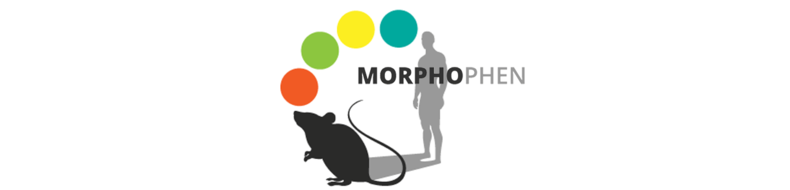


# 🧬 **Dataset Overview: RNA-Seq Analysis of iPS-Derived Neuronal Samples**  

We will be working with a publicly available dataset from the **Gene Expression Omnibus (GEO)**, which focuses on RNA-Seq analysis of purified **induced pluripotent stem (iPS) cell-derived neuronal samples**. This study investigates gene expression differences between **midbrain dopaminergic (mDA) neurons** derived from **Parkinson’s disease (PD) patients** and **healthy controls**.

## 📂 **Dataset Information**  
| **Attribute**  | **Details**  |
|---------------|-------------|
| 🔗 **GEO Accession** | [GSE62642](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE62642) |
| 📊 **Number of GEO Samples** | 14 |
| 🎞️ **Number of SRA Runs** | 14 |
| 🧬 **Species** | *Homo sapiens* |
| 📝 **Title** | RNA-Seq Analysis in Purified iPS Cell-Derived Neuronal Samples |

## 🧩 **Study Summary**  
This dataset characterizes **gene expression differences** in **midbrain dopaminergic (mDA) neurons** from:
- 🧪 **6 Parkinson’s disease (PD) cases**  
- 🧬 **8 healthy controls**  

A total of **1,028 differentially expressed genes (DEGs)** were identified, forming the **PD expression signature**. Notably, the **MAOB gene** was found to be **significantly differentially expressed** (**p = 0.046**).  


This dataset provides valuable insights into **molecular changes in PD neurons**, enabling further exploration of neurodegenerative disease mechanisms. 🚀


# 🌐 **Introduction to NetworkX: Graph Analysis in Python**

## 🔍 **What is NetworkX?**  
[NetworkX](https://networkx.org/) is a powerful Python library designed for the **creation, manipulation, and analysis** of complex networks and graphs. It provides efficient tools to model relationships between entities, analyze graph structures, and visualize networks.

## 🚀 **Why Use NetworkX?**  
NetworkX is widely used in **bioinformatics, social network analysis, transportation systems, and machine learning** due to its flexibility and ease of use. With NetworkX, you can:  
✔️ Build **undirected** and **directed** graphs  
✔️ Compute **centrality measures** (degree, betweenness, closeness)  
✔️ Detect **communities and clusters**  
✔️ Perform **pathfinding algorithms** (Dijkstra, A*)  
✔️ Generate and visualize **real-world networks**  

---

## 📌 **Key Features**  
| Feature | Description |
|---------|------------|
| 📈 **Graph Representation** | Supports multiple types of graphs (directed, undirected, multigraphs). |
| 🔗 **Network Algorithms** | Includes algorithms for shortest paths, clustering, centrality, and flow. |
| 📊 **Graph Visualization** | Integrates with Matplotlib to produce customizable network plots. |
| 🔬 **Biological Applications** | Used for modeling **gene interaction networks**, **protein-protein interactions**, and **metabolic pathways**. |

---

## 🏗️ **How Does NetworkX Work?**  
NetworkX represents a graph as a **dictionary of nodes and edges**. Each node can store attributes (e.g., gene expression values, protein functions), while edges represent **interactions or relationships** between nodes.  

### 🔹 **Example: Creating a Simple Graph**
```python
import networkx as nx
import matplotlib.pyplot as plt

# Create an empty graph
G = nx.Graph()

# Add nodes
G.add_nodes_from(["GeneA", "GeneB", "GeneC"])

# Add edges (relationships)
G.add_edges_from([("GeneA", "GeneB"), ("GeneB", "GeneC")])

# Visualize the graph
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', node_size=2000, font_size=12)
plt.show()


# 📌 **# Dependencies**

Install the necessary dependencies with `pip`

In [ ]:
! pip install stringdb
! pip install networkx pandas

Import the necessary libraries with `import`

In [ ]:
import stringdb
import networkx as nx
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 📌 **# Assembling a STRINGdb network**

## 🔗 **Pre-processing**

First we download the differential activity analysis calculated with [GREIN](https://www.ilincs.org/apps/grein/) web-tool from the GitHub repo:

In [19]:
import pandas as pd

# Define the URL of the raw CSV file
url = 'https://raw.githubusercontent.com/geogav/morphophen_networks_spatial/main/datasets/GSE62642_signatureData.csv'

# Read the CSV file directly into a pandas DataFrame
df = pd.read_csv(url)

# Display the first few rows of the dataframe
df.head()

,Ensembl_ID,Gene_symbol,Log_FoldChange,logCPM,PValue,FDR_adjusted_P.value,Power,BCOV
0,ENSG00000180543,TSPYL5,-8.249,1.873,4.362109e-17,9.724886e-13,1.0,0.610
1,ENSG00000156253,RWDD2B,-4.760,2.464,1.141343e-16,1.272255e-12,1.0,0.457
2,ENSG00000198205,ZXDA,-7.653,0.754,7.052800e-16,5.241171e-12,1.0,0.564
3,ENSG00000254245,PCDHGA3,-4.301,3.414,1.186558e-15,6.613283e-12,1.0,0.448
4,ENSG00000107438,PDLIM1,2.976,4.817,4.171822e-11,1.860132e-07,1.0,0.406


**Ensembl_ID**  
- Unique identifier for genes from the Ensembl database (e.g., `ENSG00000139618` for BRCA2).  

**Gene_symbol**  
- The gene name corresponding to the Ensembl ID (e.g., BRCA2, TP53).  

**Log_FoldChange (logFC)**  
- Log2-transformed fold change in gene expression.  
- **Positive**: Upregulated | **Negative**: Downregulated.  
- Example:  
  - `logFC = 2` → 4-fold increase.  
  - `logFC = -1` → 2-fold decrease.  

**logCPM** (Log Counts Per Million)  
- Log-transformed **average expression level** normalized as CPM.  
- Helps assess gene expression magnitude.  

**PValue** (p-value)  
- Significance test result; lower values indicate stronger evidence for differential expression.  

**FDR_adjusted_P.value (FDR)**  
- Adjusted p-value controlling for multiple testing.  
- Typically, **FDR < 0.05** indicates significant differential expression.  

**Power**  
- Statistical power of detecting differential expression for each gene.  
- Higher values indicate a **greater probability of detecting true expression differences**.  
- Depends on **sample size, effect size (logFC), and variance**.  

**BCOV (Biological Coefficient of Variation)**  
- Represents **gene-wise biological variability** in expression across samples.  
- Used to model **biological and technical variance** in differential expression analysis.  

---  
📌 **Key takeaways**:  
- **logFC** shows the magnitude and direction of change.  
- **logCPM** provides expression level insights.  
- **FDR** ensures statistical reliability.  
- **Power** reflects confidence in detecting true differences.  
- **BCOV** accounts for biological variability. 🚀  


***Remember! Why normalisation is necessary in RNA-seq?***

**Sequencing Depth & Why Normalization Matters**  

- **Sequencing Depth** refers to the total number of reads generated for a sample in RNA-seq.  
  - Higher depth → More detected transcripts.  
  - Lower depth → Fewer detected transcripts.  

- **Why Normalize?**  
  - RNA-seq samples can have **different sequencing depths**, leading to **biased expression values** if not corrected.  
  - **Normalization** ensures that expression differences reflect **biological changes**, not **technical artifacts**.  
  - Adjusts for **library size, sequencing depth, and composition biases**, making samples comparable.  
  - Essential for **accurate fold-change calculations and statistical testing** in differential expression analysis.  

- **Common Normalization Methods:**  
  - **CPM (Counts Per Million)** → Adjusts for library size.  
  - **TPM (Transcripts Per Million)** → Adjusts for gene length & library size.  
  - **TMM (Trimmed Mean of M-values, edgeR)** → Corrects composition biases.  
  - **DESeq2 normalization** → Model-based method for robust comparisons.  

📌 **Key takeaway:** Without normalization, differences in gene expression may be **artificial** rather than **biological**! 🚀  


We are going to do some pre-processing to sort-out genes with statistically significant differential expression between Control and PD

In [20]:
# Filter rows where FDR is less than  to 0.05 to keep statistically significant gene expression changes between Control and PD
filtered_df = df[df['FDR_adjusted_P.value'] < 0.05]
filtered_df.head()

,Ensembl_ID,Gene_symbol,Log_FoldChange,logCPM,PValue,FDR_adjusted_P.value,Power,BCOV
0,ENSG00000180543,TSPYL5,-8.249,1.873,4.362109e-17,9.724886e-13,1.0,0.610
1,ENSG00000156253,RWDD2B,-4.760,2.464,1.141343e-16,1.272255e-12,1.0,0.457
2,ENSG00000198205,ZXDA,-7.653,0.754,7.052800e-16,5.241171e-12,1.0,0.564
3,ENSG00000254245,PCDHGA3,-4.301,3.414,1.186558e-15,6.613283e-12,1.0,0.448
4,ENSG00000107438,PDLIM1,2.976,4.817,4.171822e-11,1.860132e-07,1.0,0.406


In [21]:
# Sort the dataframe by Log_FoldChange in descending order (to have the highest first)
filtered_df = filtered_df.sort_values(by='Log_FoldChange', ascending=False)
filtered_df

,Ensembl_ID,Gene_symbol,Log_FoldChange,logCPM,PValue,FDR_adjusted_P.value,Power,BCOV
72,ENSG00000167941,SOST,6.993,4.789,1.305371e-05,4.006424e-03,1.000,1.168
203,ENSG00000206449,MICB,6.736,-1.705,2.451351e-04,2.669996e-02,0.994,1.050
13,ENSG00000259288,BUB1B-PAK6,6.668,-0.573,1.545597e-08,2.461253e-05,1.000,0.698
90,ENSG00000237056,ZBTB22,6.121,0.055,2.524820e-05,6.217637e-03,1.000,1.049
174,ENSG00000149043,SYT8,6.081,-2.186,1.677492e-04,2.108009e-02,0.957,0.839
...,...,...,...,...,...,...,...,...
63,ENSG00000253301,LINC01606,-6.814,-1.584,6.905000e-06,2.405314e-03,0.999,0.805
8,ENSG00000143631,FLG,-7.036,0.003,6.343878e-09,1.429571e-05,1.000,0.755
2,ENSG00000198205,ZXDA,-7.653,0.754,7.052800e-16,5.241171e-12,1.000,0.564
0,ENSG00000180543,TSPYL5,-8.249,1.873,4.362109e-17,9.724886e-13,1.000,0.610


In [22]:
filtered_df.to_csv('PD_DEGs.csv', index=False)

In [23]:
genes = filtered_df['Gene_symbol'].tolist()
genes

['SOST',
 'MICB',
 'BUB1B-PAK6',
 'ZBTB22',
 'SYT8',
 'IL1B',
 'KLK5',
 'HP',
 'PF4V1',
 'GATA3-AS1',
 'TYR',
 'OR8S1',
 'LINC00968',
 'TCERG1L',
 'HLA-F',
 'CCL18',
 'AFP',
 'HAND2',
 'S1PR5',
 'MSX2',
 'HTR3A',
 'MS4A6A',
 'MS4A6E',
 'PTH1R',
 'IL1A',
 'SLN',
 'AMY1C',
 'GPR87',
 'GCNT4',
 'IGFBP3',
 'TLR4',
 'SERPINE1',
 'PIRT',
 'ACTA2',
 'ITGA11',
 'DIO2',
 'ANKRD1',
 'ACTG2',
 'CFH',
 'GATA3',
 'WSCD2',
 'PLAU',
 'SPHK1',
 'RPE65',
 'LINC01411',
 'LRRC14B',
 'MYL3',
 'SELE',
 'PDPN',
 'IGFBP7',
 'LINC00052',
 'MYL9',
 'FAM135B',
 'C6',
 'COL11A1',
 'IFITM1',
 'STEAP3',
 'KLK6',
 'PLA2G2A',
 'HOPX',
 'CFB',
 'OMG',
 'PDLIM1',
 'CFB',
 'PROCR',
 'CTSV',
 'LAYN',
 'CCL2',
 'CFB',
 'CFB',
 'CASP4',
 'CAVIN1',
 'C7',
 'CARTPT',
 'CDKN2B',
 'LIF',
 'CDCP1',
 'P3H2',
 'COLEC12',
 'D21S2088E',
 'FZD10',
 'TAGLN',
 'NRAP',
 'APOE',
 'TRIM55',
 'LOC153684',
 'PRPH',
 'ALDH1A1',
 'PCP4',
 'CLEC3A',
 'ANGPTL4',
 'GPNMB',
 'KCNE1',
 'BMPER',
 'ASS1',
 'IFIT1',
 'THBS1',
 'GBP1',
 'CRISPLD1',


We isolated all the gene names. Now we can do the same for the upregulated genes.

In [24]:
# Isolate differentially over-expressed genes
upgenes_df = filtered_df[filtered_df['Log_FoldChange'] > 0]
upgenes_df

,Ensembl_ID,Gene_symbol,Log_FoldChange,logCPM,PValue,FDR_adjusted_P.value,Power,BCOV
72,ENSG00000167941,SOST,6.993,4.789,1.305371e-05,0.004006,1.000,1.168
203,ENSG00000206449,MICB,6.736,-1.705,2.451351e-04,0.026700,0.994,1.050
13,ENSG00000259288,BUB1B-PAK6,6.668,-0.573,1.545597e-08,0.000025,1.000,0.698
90,ENSG00000237056,ZBTB22,6.121,0.055,2.524820e-05,0.006218,1.000,1.049
174,ENSG00000149043,SYT8,6.081,-2.186,1.677492e-04,0.021080,0.957,0.839
...,...,...,...,...,...,...,...,...
283,ENSG00000164111,ANXA5,1.134,7.831,4.575175e-04,0.036017,0.998,0.312
257,ENSG00000140538,NTRK3,1.091,5.816,3.921102e-04,0.033927,0.997,0.296
239,ENSG00000111859,NEDD9,1.067,6.242,3.325817e-04,0.030894,0.998,0.287
293,ENSG00000145012,LPP,0.988,5.905,5.184037e-04,0.039374,0.995,0.275


In [25]:
# Make a list of the gene names - we need that to send it to STRINGdb
upgenes_list = upgenes_df['Gene_symbol'].tolist()
upgenes_list

['SOST',
 'MICB',
 'BUB1B-PAK6',
 'ZBTB22',
 'SYT8',
 'IL1B',
 'KLK5',
 'HP',
 'PF4V1',
 'GATA3-AS1',
 'TYR',
 'OR8S1',
 'LINC00968',
 'TCERG1L',
 'HLA-F',
 'CCL18',
 'AFP',
 'HAND2',
 'S1PR5',
 'MSX2',
 'HTR3A',
 'MS4A6A',
 'MS4A6E',
 'PTH1R',
 'IL1A',
 'SLN',
 'AMY1C',
 'GPR87',
 'GCNT4',
 'IGFBP3',
 'TLR4',
 'SERPINE1',
 'PIRT',
 'ACTA2',
 'ITGA11',
 'DIO2',
 'ANKRD1',
 'ACTG2',
 'CFH',
 'GATA3',
 'WSCD2',
 'PLAU',
 'SPHK1',
 'RPE65',
 'LINC01411',
 'LRRC14B',
 'MYL3',
 'SELE',
 'PDPN',
 'IGFBP7',
 'LINC00052',
 'MYL9',
 'FAM135B',
 'C6',
 'COL11A1',
 'IFITM1',
 'STEAP3',
 'KLK6',
 'PLA2G2A',
 'HOPX',
 'CFB',
 'OMG',
 'PDLIM1',
 'CFB',
 'PROCR',
 'CTSV',
 'LAYN',
 'CCL2',
 'CFB',
 'CFB',
 'CASP4',
 'CAVIN1',
 'C7',
 'CARTPT',
 'CDKN2B',
 'LIF',
 'CDCP1',
 'P3H2',
 'COLEC12',
 'D21S2088E',
 'FZD10',
 'TAGLN',
 'NRAP',
 'APOE',
 'TRIM55',
 'LOC153684',
 'PRPH',
 'ALDH1A1',
 'PCP4',
 'CLEC3A',
 'ANGPTL4',
 'GPNMB',
 'KCNE1',
 'BMPER',
 'ASS1',
 'IFIT1',
 'THBS1',
 'GBP1',
 'CRISPLD1',


We know filter the down-regulated genes.

In [26]:
# Isolate differentially under-expressed genes
downgenes_df = filtered_df[filtered_df['Log_FoldChange'] < 0]
downgenes_df

,Ensembl_ID,Gene_symbol,Log_FoldChange,logCPM,PValue,FDR_adjusted_P.value,Power,BCOV
278,ENSG00000158164,TMSB15A,-0.928,5.585,4.565908e-04,3.601737e-02,0.992,0.255
327,ENSG00000254995,STX16-NPEPL1,-0.968,5.836,6.809158e-04,4.642127e-02,0.993,0.275
315,ENSG00000197093,GAL3ST4,-0.997,5.577,6.253891e-04,4.425732e-02,0.992,0.281
297,ENSG00000134294,SLC38A2,-1.015,7.770,5.552283e-04,4.153779e-02,0.998,0.284
236,ENSG00000153956,CACNA2D1,-1.043,8.026,3.216407e-04,3.025594e-02,0.999,0.280
...,...,...,...,...,...,...,...,...
63,ENSG00000253301,LINC01606,-6.814,-1.584,6.905000e-06,2.405314e-03,0.999,0.805
8,ENSG00000143631,FLG,-7.036,0.003,6.343878e-09,1.429571e-05,1.000,0.755
2,ENSG00000198205,ZXDA,-7.653,0.754,7.052800e-16,5.241171e-12,1.000,0.564
0,ENSG00000180543,TSPYL5,-8.249,1.873,4.362109e-17,9.724886e-13,1.000,0.610


In [27]:
# Make a list of the gene names - we need that to send it to STRINGdb
downgenes_list = downgenes_df['Gene_symbol'].tolist()
downgenes_list

['TMSB15A',
 'STX16-NPEPL1',
 'GAL3ST4',
 'SLC38A2',
 'CACNA2D1',
 'ZNF333',
 'YPEL1',
 'IGSF9',
 'GLCCI1',
 'USP49',
 'TNRC6C',
 'LPAR2',
 'HCN3',
 'HCN3',
 'KLHDC8A',
 'ZNF382',
 'CELF3',
 'SLC4A7',
 'TRIM36',
 'RGMA',
 'CELSR3',
 'SH2D3C',
 'CARMIL3',
 'PCBP4',
 'SLC1A2',
 'RNF165',
 'FAM57B',
 'MYT1',
 'MYT1',
 'SCRT1',
 'MEX3B',
 'PCDHGC3',
 'LRP8',
 'GREM2',
 'DGKB',
 'PNCK',
 'GPM6A',
 'LRRC61',
 'SLITRK3',
 'GRIK2',
 'GLYCTK',
 'DRD2',
 'LMO3',
 'PLCL2',
 'MTUS2',
 'ZNF441',
 'KCNH8',
 'CNGA3',
 'RAMP2-AS1',
 'ADCYAP1',
 'ANK1',
 'RNF112',
 'GRIA2',
 'DCC',
 'OPCML',
 'SV2B',
 'PDZRN4',
 'DSCAML1',
 'GLRA2',
 'POU2F2',
 'DGKK',
 'FAM66C',
 'DSCAM',
 'INSM2',
 'HRC',
 'ZBED6CL',
 'INHBA-AS1',
 'MMP10',
 'HSPA2',
 'CNGB1',
 'TRPC5',
 'GALNT9',
 'ZNF385D',
 'NR4A2',
 'ASIC4',
 'CDH12',
 'ZNF726',
 'HTR1A',
 'C1QL1',
 'TH',
 'C5orf17',
 'C11orf70',
 'LHX5',
 'ZNF98',
 'ZNF676',
 'ZNF676',
 'ZNF681',
 'CISTR',
 'KIFC1',
 'PCDHGA7',
 'ZNF208',
 'CPLX3',
 'PCDHA13',
 'CTSF',
 'PCDHGA3

## 🔗 **Mapping Genes to STRINGdb: A Critical Step in Network Construction**  

In this step, we map our **genes of interest** to **STRINGdb**, a widely-used biological database that provides:  
✔️ **Protein-protein interaction (PPI) networks**  
✔️ **Functional associations** (co-expression, co-occurrence, pathway membership)  
✔️ **Experimental and computational evidence** supporting each interaction  

### 📌 **Why is This Step Important?**  
Mapping genes to STRINGdb allows us to:  
✅ **Retrieve high-confidence interactions** between proteins  
✅ **Integrate multi-omic datasets** for systems biology analysis  
✅ **Expand our network** by adding functionally relevant connections  
✅ **Perform enrichment analysis** to detect key pathways  

### 🧬 **How STRINGdb Works**  
STRINGdb assigns a **unique identifier** to each mapped gene or protein, allowing us to:  
- Cross-reference multiple **species and gene naming conventions**  
- Retrieve **experimentally validated** and **predicted interactions**  
- Construct **biologically meaningful networks**  


In [28]:
string_ids = stringdb.get_string_ids(genes, species = 9606)   # human is 'species=9606'
network_df = stringdb.get_network(string_ids.queryItem, species = 9606, required_score=400)

In [29]:
# Perform pathway enrichment
enrichment_df = stringdb.get_enrichment(string_ids.queryItem, species = 9606)
enrichment_df

,category,term,number_of_genes,number_of_genes_in_background,ncbiTaxonId,inputGenes,preferredNames,p_value,fdr,description
0,COMPARTMENTS,GOCC:0005576,80,2079,9606,"VCL,PROCR,CTSH,SERPINE1,ACTA2,CCL2,PF4V1,TTR,T...","VCL,PROCR,CTSH,SERPINE1,ACTA2,CCL2,PF4V1,TTR,T...",2.070000e-13,4.750000e-10,Extracellular region
1,COMPARTMENTS,GOCC:0071944,118,3860,9606,"CELSR3,VCL,PROCR,GLRA2,SERPINE1,FZD10,TGFB3,OM...","CELSR3,VCL,PROCR,GLRA2,SERPINE1,FZD10,TGFB3,OM...",4.140000e-13,4.760000e-10,Cell periphery
2,COMPARTMENTS,GOCC:0030054,47,1053,9606,"VCL,PROCR,GLRA2,APOE,PDGFRB,CDH6,EGFR,SLC1A2,G...","VCL,PROCR,GLRA2,APOE,PDGFRB,CDH6,EGFR,SLC1A2,G...",5.200000e-10,3.990000e-07,Cell junction
3,COMPARTMENTS,GOCC:0030312,22,259,9606,"SERPINE1,TGFB3,APOE,MATN2,THBS1,LTBP2,IL1B,TIM...","SERPINE1,TGFB3,APOE,MATN2,THBS1,LTBP2,IL1B,TIM...",8.430000e-10,4.850000e-07,External encapsulating structure
4,COMPARTMENTS,GOCC:0031012,22,259,9606,"SERPINE1,TGFB3,APOE,MATN2,THBS1,LOXL1,LTBP2,IL...","SERPINE1,TGFB3,APOE,MATN2,THBS1,LOXL1,LTBP2,IL...",8.430000e-10,4.850000e-07,Extracellular matrix
...,...,...,...,...,...,...,...,...,...,...
557,NetworkNeighborAL,CL:22574,7,57,9606,"ACTA2,MYL9,TPM1,TAGLN,ACTG2,TPM2,MYL3","ACTA2,MYL9,TPM1,TAGLN,ACTG2,TPM2,MYL3",6.700000e-05,3.410000e-02,"Muscle protein, and Myosin light chain kinase ..."
558,NetworkNeighborAL,CL:18723,12,196,9606,"PROCR,SERPINE1,APOE,C6,ANGPTL4,LRP8,C7,OLFML3,...","PROCR,SERPINE1,APOE,C6,ANGPTL4,LRP8,C7,OLFML3,...",1.300000e-04,4.420000e-02,"Mixed, incl. Complement and coagulation cascad..."
559,NetworkNeighborAL,CL:18726,11,161,9606,"PROCR,SERPINE1,APOE,C6,ANGPTL4,LRP8,C7,HP,CFH,...","PROCR,SERPINE1,APOE,C6,ANGPTL4,LRP8,C7,HP,CFH,...",9.710000e-05,4.420000e-02,"Complement and coagulation cascades, and Prote..."
560,NetworkNeighborAL,CL:19272,4,12,9606,"S100A11,ANXA2,AHNAK,ANXA11","S100A11,ANXA2,AHNAK,ANXA11",9.670000e-05,4.420000e-02,"Mixed, incl. Positive regulation of plasma mem..."


In [ ]:
# Create a Networkx model

G = nx.Graph()

#Add edges to the graph from the DataFrame
for index, row in network_df.iterrows():
    G.add_edge(row['preferredName_A'], row['preferredName_B'], weight=row['score'])

# Draw the graph
pos = nx.spring_layout(G)  # positions for all nodes
nx.draw(G, pos, with_labels=True, node_size=700, node_color='lightblue', font_size=10)

# Draw edge labels with weights
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()

KeyboardInterrupt: 

Improving the visualisation is important to gain a better understanding.

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a Networkx model
G = nx.Graph()

# Add edges to the graph from the DataFrame
for index, row in network_df.iterrows():
    G.add_edge(row['preferredName_A'], row['preferredName_B'], weight=row['score'])

# Set the layout with relaxed parameters
pos = nx.spring_layout(G, k=0.5, iterations=50)  # Increase 'k' for more space between nodes, increase 'iterations' for convergence

# Create a larger figure to avoid overcrowding
plt.figure(figsize=(12, 12))

# Draw the graph
nx.draw(G, pos, with_labels=True, node_size=700, node_color='lightblue', font_size=6)

# Draw edge labels with weights
# edge_labels = nx.get_edge_attributes(G, 'weight')
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Show the plot
plt.show()

Reading through the node and edge attributes is very important to keep track of network meta-data.

In [ ]:
# Sanity check 2: Inspect node attributes
node_attributes = {node: G.nodes[node] for node in G.nodes()}
node_df = pd.DataFrame(node_attributes).T

print("Node Attributes:")
print(node_df)

In [ ]:
# Sanity check 1: Inspect edge attributes
edge_attributes = [{'source': source, 'target': target, **attr}
                   for source, target, attr in G.edges(data=True)]

edge_df = pd.DataFrame(edge_attributes)

print("Edge Attributes:")
print(edge_df)

In [ ]:
# Sanity check 2: Inspect node attributes
node_attributes = {node: G.nodes[node] for node in G.nodes()}
node_df = pd.DataFrame(node_attributes).T

print("Node Attributes:")
print(node_df)

## 🎨 **Incorporating Differential Expression as Node Attributes**  

### 📌 **Why is This Important?**  
In biological networks, **not all genes are equal**—some show significant **upregulation or downregulation** in response to conditions like disease, treatment, or genetic perturbation. By integrating **differential expression (DE) values** into our network as **node attributes**, we gain a more **informative and interpretable visualization**.

### 🔬 **Biological Significance of Coloring Nodes**  
✔ **Highlights key regulatory genes** driving biological changes  
✔ **Distinguishes upregulated (high expression) vs. downregulated (low expression) genes**  
✔ **Reveals network-wide expression trends** that may indicate functional modules  
✔ **Enhances pattern recognition** by grouping co-expressed genes  

---

## 🎨 **Coloring Nodes with a Gradient: A Visual Advantage**  
Using a **color gradient** to represent log fold change (**logFC**) values allows us to intuitively interpret expression levels:

🔴 **Red Shades → Upregulated Genes**  
🔵 **Blue Shades → Downregulated Genes**  
⚫ **Gray/Neutral → Non-significant Genes**  

This approach helps in:  
- **Spotting key clusters of up/down-regulated genes**  
- **Identifying potential functional hubs**  
- **Comparing differentially expressed genes across conditions**  

---

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# Assuming 'df' is the DataFrame containing your differential expression data
# and 'G' is your NetworkX graph with node names as gene symbols

# Create a mapping from gene_symbol to Log_FoldChange
gene_to_logfc = dict(zip(df['Gene_symbol'], df['Log_FoldChange']))

# Add the Log_FoldChange values as node attributes in the graph
for node in G.nodes():
    if node in gene_to_logfc:  # Check if the node is in the gene_to_logfc mapping
        G.nodes[node]['Log_FoldChange'] = gene_to_logfc[node]

# Now, color the nodes based on their Log_FoldChange value
logfc_values = [G.nodes[node].get('Log_FoldChange', 0) for node in G.nodes()]
norm = plt.Normalize(min(logfc_values), max(logfc_values))  # Normalize the values
colors = [cm.coolwarm(norm(logfc)) for logfc in logfc_values]  # Use continuous blue-to-red colormap

# Set up the layout for the graph
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Create a larger figure
fig, ax = plt.subplots(figsize=(16, 16))

# Draw the graph
nx.draw(G, pos, with_labels=True, node_size=700, node_color=colors, font_size=10, ax=ax)

# Optionally, draw edge labels if needed
# edge_labels = nx.get_edge_attributes(G, 'weight')
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax)

# Add a continuous color bar with a title and adjust its size using the shrink parameter
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)  # Create a ScalarMappable object
sm.set_array([])  # Associate an empty array (required)
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.04)  # shrink the color bar to 50% of its size
cbar.set_label("Log Fold Change")  # Set the color bar title

# Show the plot
plt.show()

# 📌 **# Network statistics**

## 📊 **Understanding Network Statistics: Why They Matter**  

### 🔍 **Why Analyze Network Statistics?**  
Biological networks are **not random**—they have **underlying structures and patterns** that can reveal critical biological insights. **Network statistics** help us **quantify these structures**, providing a mathematical foundation for understanding:  

✔ **Key genes (hubs) and their influence**  
✔ **How information or signals propagate in a network**  
✔ **The modular organization of biological pathways**  
✔ **The robustness and vulnerability of the system**  

By computing **network statistics**, we can compare biological networks, identify disease-related genes, and detect functional modules.  

---

### 📌 **Key Network Metrics and Their Biological Relevance**  

| **Metric** | **Description** | **Why It’s Important in Biology?** |
|------------|---------------|----------------------------------|
| **Degree** (k) | Number of edges connected to a node | Identifies **hub genes** with high connectivity, often **essential for cellular functions** |
| **Betweenness Centrality** | Fraction of shortest paths passing through a node | Detects **bottleneck genes** that act as **bridges between pathways** |
| **Clustering Coefficient** | Measures how well a node's neighbors are connected | Reveals **functional clusters** and **gene co-expression modules** |
| **Shortest Path Length** | Smallest number of edges between two nodes | Helps understand **gene interaction efficiency** |
| **Network Density** | Ratio of observed edges to possible edges | Differentiates between **highly connected vs. sparse networks** |
| **Modularity** | Measures the presence of densely connected subgroups | Identifies **functional communities**, such as protein complexes |
| **Assortativity** | Measures whether nodes tend to connect to similar nodes | Explores **gene interaction preferences** and **evolutionary constraints** |

---

### 🔬 **Why Are These Statistics Crucial for Biological Networks?**  
📌 **Identifying Disease Genes**: Disease-related genes often show high **centrality**, meaning they are crucial in the **network topology**.  
📌 **Drug Target Discovery**: Genes with high **betweenness centrality** may serve as **targets for drug interventions** since they control information flow.  
📌 **Understanding Pathway Interactions**: Clustering and modularity metrics help **detect functional gene groups** involved in diseases or metabolic pathways.  

---

In [ ]:
num_nodes = G.number_of_nodes()  # Returns the total number of nodes in the graph
num_edges = G.number_of_edges()  # Returns the total number of edges in the graph

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)

In [ ]:
if nx.is_connected(G):
    print("The graph is connected.")
else:
    print("The graph is not connected.")

In [ ]:
# Identify the largest connected component
largest_cc = max(nx.connected_components(G), key=len)
G_largest = G.subgraph(largest_cc).copy()

# Now compute the shortest path metrics on this largest component
avg_sp_largest = nx.average_shortest_path_length(G_largest)
diameter_largest = nx.diameter(G_largest)

print("Average shortest path length in the largest component:", avg_sp_largest)
print("Diameter of the largest component:", diameter_largest)

In [ ]:
import networkx as nx
import numpy as np

# Assuming G is your pre-built NetworkX graph

# 1. Degree information
degree_sequence = [d for n, d in G.degree()]
avg_degree = np.mean(degree_sequence)

# 2. Betweenness centrality
bet_centrality = nx.betweenness_centrality(G)
avg_betweenness = np.mean(list(bet_centrality.values()))

# 3. Average shortest path length and diameter (if the graph is connected)
if nx.is_connected(G):
    avg_shortest_path = nx.average_shortest_path_length(G)
    diameter = nx.diameter(G)
else:
    avg_shortest_path = None
    diameter = None

# 4. Clustering coefficient
avg_clustering = nx.average_clustering(G)

# 5. Degree assortativity coefficient
assortativity = nx.degree_assortativity_coefficient(G)

# Print the computed statistics for context
print("Average degree:", avg_degree)
print("Average betweenness centrality:", avg_betweenness)
if avg_shortest_path is not None:
    print("Average shortest path length:", avg_shortest_path)
    print("Diameter:", diameter)
else:
    print("Graph is not connected; shortest path length and diameter not computed.")
print("Average clustering coefficient:", avg_clustering)
print("Degree assortativity coefficient:", assortativity)

Let's verify that our STRINGdb network is a Scale-free Network

In [ ]:
import matplotlib.pyplot as plt

# Plot the degree distribution for the original network
plt.figure(figsize=(12, 6))

# Create a histogram for the original network's degree distribution
bins = range(min(degree_sequence), max(degree_sequence) + 2)  # bins from min to max degree + 1
plt.hist(degree_sequence, bins=bins, density=True, alpha=0.5, label="Original Network")

plt.xlabel("Degree (k)")
plt.ylabel("Probability P(k)")
plt.title("Degree Distribution of the Original Network")
plt.legend()
plt.show()

In [ ]:
# Generate a random network with the same number of nodes and edges as G
n = G.number_of_nodes()
m = G.number_of_edges()
G_random = nx.gnm_random_graph(n, m)

# Calculate the degree distribution for the random network
degree_sequence_random = [d for n, d in G_random.degree()]

# Plot the degree distribution for the random network along with the original network
plt.figure(figsize=(12, 6))
plt.hist(degree_sequence, bins=range(min(degree_sequence), max(degree_sequence) + 2),
         density=True, alpha=0.5, label="Original Network")
plt.hist(degree_sequence_random, bins=range(min(degree_sequence_random), max(degree_sequence_random) + 2),
         density=True, alpha=0.5, label="Random Network")

plt.xlabel("Degree (k)")
plt.ylabel("Probability P(k)")
plt.title("Degree Distribution Comparison: Original vs Random Network")
plt.legend()
plt.show()


## 📌 # Network Metrics Analysis

### Average Degree (≈ 6.92)
On average, each node in the network is connected to about 7 other nodes. This indicates a moderate level of connectivity among the nodes.

### Average Betweenness Centrality (≈ 0.0081)
Betweenness centrality measures how often a node acts as a bridge along the shortest path between two other nodes. A low average value (0.0081) suggests that, on average, nodes are not acting as critical connectors in the network, meaning that information or influence likely flows through multiple alternative paths.

### Graph Not Connected
The network consists of multiple disconnected components rather than forming one single connected network. As a result, metrics that require a fully connected graph—such as average shortest path length and diameter—cannot be computed for the entire network.

### Average Clustering Coefficient (≈ 0.316)
This coefficient measures the tendency of nodes to cluster together (i.e., the likelihood that two neighbors of a node are also connected). An average clustering coefficient of about 0.316 suggests that there is some clustering in the network, but the nodes are not forming very dense clusters overall.

### Degree Assortativity Coefficient (≈ 0.038)
Degree assortativity measures the tendency of nodes to connect to other nodes with similar degree. A value near zero (0.038) indicates little to no correlation between the degrees of connected nodes—meaning that high-degree nodes are not particularly more likely to connect to other high-degree nodes (or low-degree nodes).

---

**Summary:**  
These metrics provide insight into the overall structure and connectivity of your network, highlighting its moderate connectivity, low centralization in terms of bridging nodes, and a lack of strong preferential attachment among nodes based on their degree.


In [ ]:
# import pandas as pd

# # Get the list of node names from the graph G
# node_names = list(G.nodes())

# # Create a DataFrame
# df_nodes = pd.DataFrame(node_names, columns=["Node_Name"])

# # Save the DataFrame to a CSV file (without the index)
# df_nodes.to_csv("node_names.csv", index=False)

Our graph has smaller probably dyadic network "islands"; let's seek them out:

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Extract all connected components
components = list(nx.connected_components(G))

# Find dyads (subgraphs with exactly 2 nodes)
dyads = [comp for comp in components if len(comp) == 2]

# Plot each dyad separately
fig, axes = plt.subplots(1, len(dyads), figsize=(2 * len(dyads), 3))

if len(dyads) == 1:  # If there's only one dyad, make axes iterable
    axes = [axes]

for i, dyad in enumerate(dyads):
    subgraph = G.subgraph(dyad)
    pos = nx.spring_layout(subgraph)  # Layout for visualization
    nx.draw(subgraph, pos, with_labels=True, node_color="lightblue", edge_color="gray", ax=axes[i])
    axes[i].set_title(f"Dyad {i+1}")

plt.suptitle("Dyadic Small Networks (2-Node Subgraphs)")
plt.show()


We are going to visualise the main component of our graph here:

In [ ]:
# Identify the largest connected component
largest_cc = max(nx.connected_components(G), key=len)

# Create a subgraph from the largest component
G_largest = G.subgraph(largest_cc).copy()

# Plot the largest connected component
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G_largest, k=0.5)  # Layout for better spacing
nx.draw(G_largest, pos, with_labels=True, node_size=500, node_color="lightblue", edge_color="gray", font_size=10)

plt.title("Largest Connected Component of the Network")
plt.show()

## 📌 # Centrality ranking

## 🎯 **Centrality Analysis: Identifying Key Nodes in Biological Networks**  

## 🔍 **What is Centrality Analysis?**  
Centrality analysis helps us **identify the most important nodes** in a network. In **biological networks**, these central nodes often correspond to **key regulators, essential genes, or drug targets**.  

By analyzing **centrality measures**, we can detect:  
✔️ **Hub genes** that have many connections and influence the network  
✔️ **Bridging nodes** that control communication between different pathways  
✔️ **Genes critical for disease progression**  

---

## 📌 **Key Centrality Measures and Their Biological Relevance**  

| **Centrality Measure** | **Description** | **Why It’s Important in Biology?** |
|------------------------|----------------|----------------------------------|
| **Degree Centrality** | Number of direct connections a node has | Identifies **hub genes** with high connectivity, often essential for survival |
| **Betweenness Centrality** | Fraction of shortest paths passing through a node | Detects **bottleneck genes** that control information flow between modules |
| **Closeness Centrality** | Measures how easily a node can reach all others | Highlights genes that are **efficient communicators** in regulatory networks |
| **Eigenvector Centrality** | Accounts for both the quantity and quality of connections | Identifies **highly influential genes** that interact with other central genes |
| **PageRank** | Similar to Eigenvector but with weight-based influence | Used for **ranking genes in signaling networks** |
| **Harmonic Centrality** | A variation of closeness centrality that works better on disconnected networks | Useful for analyzing **disease-associated subnetworks** |

---

## 🔬 **Why is Centrality Analysis Crucial for Biological Networks?**  
📌 **Identifying Disease Genes**: Genes with high centrality may play key roles in **disease progression** (e.g., TP53 in cancer).  
📌 **Drug Target Discovery**: Central genes often make **good therapeutic targets** due to their influence on network stability.  
📌 **Functional Module Detection**: High-centrality nodes often belong to **critical biological pathways** and can help define gene communities.  

---


In [ ]:
import pandas as pd
import networkx as nx

# Compute centrality measures
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

# Create a DataFrame with rankings
df_centrality = pd.DataFrame({
    "Gene": list(degree_centrality.keys()),
    "Degree Centrality": list(degree_centrality.values()),
    "Betweenness Centrality": list(betweenness_centrality.values()),
    "Closeness Centrality": list(closeness_centrality.values())
})

# Rank genes based on each centrality metric
df_centrality["Degree Rank"] = df_centrality["Degree Centrality"].rank(ascending=False, method="min")
df_centrality["Betweenness Rank"] = df_centrality["Betweenness Centrality"].rank(ascending=False, method="min")
df_centrality["Closeness Rank"] = df_centrality["Closeness Centrality"].rank(ascending=False, method="min")

# Sort by degree centrality (or any other preferred metric)
df_centrality = df_centrality.sort_values(by="Degree Centrality", ascending=False)
df_centrality.head(10)

In [ ]:
# df_centrality.to_csv("gene_centrality_rankings.csv", index=False)
# print("Centrality rankings saved to gene_centrality_rankings.csv")

# 📌 **# Clustering**

## 🔗 **Clustering in Networks: Understanding Modular Organization**  

### 🔍 **What is Clustering in Networks?**  
Clustering refers to the **tendency of nodes to form tightly connected groups**, also known as **modules or communities**. In **biological networks**, clustering is particularly important because it helps identify:  

✔ **Functionally related genes** working together  
✔ **Protein-protein interaction (PPI) complexes**  
✔ **Disease-related gene modules**  
✔ **Signaling and metabolic pathways**  

---

### 📌 **Key Clustering Concepts**  

| **Concept** | **Description** | **Why It’s Important in Biology?** |
|------------|----------------|----------------------------------|
| **Clustering Coefficient** | Measures how well a node's neighbors are connected to each other | Identifies tightly connected **functional modules** |
| **Community Detection** | Groups nodes based on dense interconnections | Helps define **gene expression clusters** and **disease-associated subnetworks** |
| **Modularity** | Measures how well a network is divided into distinct communities | Reveals **functional separation of biological processes** |
| **Louvain Algorithm** | A popular method for detecting hierarchical community structures | Used to **find gene modules in large-scale omics data** |

---

### 🔬 **Why is Clustering Important for Biological Networks?**  
📌 **Identifying Functional Modules**: Genes in the same cluster often belong to the same **biological pathway or protein complex**.  
📌 **Disease Subnetwork Detection**: Clusters may represent **genetic signatures of diseases** (e.g., cancer-related gene clusters).  
📌 **Enhancing Network Interpretability**: Instead of analyzing a large, complex network, clustering allows us to **break it down into meaningful subgroups**.  

---

***We will perform various clustering strategies on the largest connected component***

In [ ]:
# Step 1: Extract the Largest Connected Component (LCC)
largest_cc = max(nx.connected_components(G), key=len)  # Get the largest component
G = G.subgraph(largest_cc).copy()  # Make G the largest connected component

## 📌 1️⃣ Edge Betweenness Clustering (Girvan-Newman Algorithm)
The Girvan-Newman algorithm removes edges with high betweenness to find network communities.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import girvan_newman

# Step 1: Compute Edge Betweenness Clustering (Girvan-Newman)
communities = next(girvan_newman(G))  # Get first split of communities

# Step 2: Convert to a dictionary for visualization
community_mapping = {node: i for i, comm in enumerate(communities) for node in comm}

# Step 3: Assign Community Labels to Nodes
nx.set_node_attributes(G, community_mapping, "community")

# Step 4: Define Positioning and Colors
pos = nx.spring_layout(G, k=1.0, seed=42)  # Open representation with more space
cmap = plt.get_cmap("Set3")  # Distinct colors for different communities
node_colors = [cmap(community_mapping[node] % 12) for node in G.nodes()]  # Max 12 unique colors

# Step 5: Improved Visualization
plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(G, pos, alpha=0.4, width=0.8, edge_color="gray")  # Less intrusive edges
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, edgecolors="black", linewidths=1.2)  # Nodes with black borders
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")  # Readable labels

plt.title("Edge Betweenness Clustering (Girvan-Newman)", fontsize=16, fontweight="bold")
plt.show()

In [ ]:
from networkx.algorithms.community import girvan_newman

# Compute edge betweenness clustering (Girvan-Newman)
communities = next(girvan_newman(G))  # Get first split of communities

# Convert to a dictionary for visualization
community_mapping = {node: i for i, comm in enumerate(communities) for node in comm}

# Assign community labels to nodes
nx.set_node_attributes(G, community_mapping, "community")

# Visualize
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G)
nx.draw(G, pos, node_color=[community_mapping[node] for node in G.nodes()], cmap=plt.cm.Set3, with_labels=True)
plt.title("Edge Betweenness Clustering (Girvan-Newman)")
plt.show()

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from networkx.algorithms.community import girvan_newman

# Step 1: Compute Edge Betweenness Clustering (Girvan-Newman)
communities = next(girvan_newman(G))  # Get first split of communities

# Step 2: Convert to a dictionary for visualization
community_mapping = {node: i for i, comm in enumerate(communities) for node in comm}

# Step 3: Assign Community Labels to Nodes
nx.set_node_attributes(G, community_mapping, "community")

# Function to generate cluster-aware layout
def community_layout(G, community_mapping, scale=3.0):
    """
    Positions nodes of the same community closer together.
    """
    pos = nx.spring_layout(G, seed=42, k=0.6)  # Initial layout
    cluster_pos = {}  # Store cluster center positions
    num_communities = len(set(community_mapping.values()))

    # Assign cluster centers using a circular layout
    angle_step = 2 * np.pi / num_communities
    for i, community in enumerate(set(community_mapping.values())):
        x, y = np.cos(i * angle_step), np.sin(i * angle_step)
        cluster_pos[community] = np.array([x, y]) * scale  # Spread communities

    # Adjust node positions within clusters
    for node in G.nodes():
        comm_id = community_mapping[node]
        pos[node] = cluster_pos[comm_id] + 0.5 * pos[node]  # Pull nodes toward cluster centers

    return pos

# Step 4: Define Positioning and Colors
pos = community_layout(G, community_mapping, scale=3.5)  # Clustered node placement
cmap = plt.get_cmap("Set3")  # Distinct colors for different communities
node_colors = [cmap(community_mapping[node] % 12) for node in G.nodes()]  # Max 12 unique colors

# Step 5: Improved Visualization
plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(G, pos, alpha=0.4, width=0.8, edge_color="gray")  # Less intrusive edges
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, edgecolors="black", linewidths=1.2)  # Nodes with black borders
nx.draw_networkx_labels(G, pos, font_size=8)  # Readable labels

plt.title("Girvan-Newman Clustering with Grouped Nodes", fontsize=16, fontweight="bold")
plt.show()

In [ ]:
# !pip install adjustText

## 📌 2️⃣ K-Means Clustering
We can use spectral clustering on the network adjacency matrix as input for K-means.

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 1: Convert NetworkX Graph to an Adjacency Matrix
adj_matrix = nx.to_numpy_array(G)

# Step 2: Perform K-means Clustering (Adjust clusters as needed)
n_clusters = 3  # Change if needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(adj_matrix)

# Step 3: Assign Cluster Labels to Nodes
cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}
nx.set_node_attributes(G, cluster_dict, "kmeans_cluster")

# Step 4: Define Positioning and Colors
pos = nx.spring_layout(G, k=0.9, seed=42)  # Spreads out nodes better
cmap = plt.get_cmap("Set1")  # Distinct colors for clusters
node_colors = [cmap(cluster_dict[node] % 9) for node in G.nodes()]

# Step 5: Improved Visualization
plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(G, pos, alpha=0.5, width=0.8, edge_color="gray")  # Less cluttered edges
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, edgecolors="black", linewidths=1.2)  # Nodes with borders
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")  # Bold labels

plt.title("K-Means Clustering on NetworkX Graph", fontsize=16, fontweight="bold")
plt.show()

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 1: Convert NetworkX Graph to an Adjacency Matrix
adj_matrix = nx.to_numpy_array(G)

# Step 2: Perform K-means Clustering
n_clusters = 3  # Change if needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(adj_matrix)

# Step 3: Assign Cluster Labels to Nodes
cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}
nx.set_node_attributes(G, cluster_dict, "kmeans_cluster")

# Function to generate a cluster-aware layout
def clustered_layout(G, cluster_dict, scale=3.5, spread_factor=0.6):
    """
    Adjusts node positions to keep clusters together while ensuring separation.
    """
    pos = nx.spring_layout(G, seed=42, k=0.6)  # Initial layout
    cluster_pos = {}  # Store cluster center positions
    num_clusters = len(set(cluster_dict.values()))

    # Assign cluster centers using a circular layout
    angle_step = 2 * np.pi / num_clusters
    for i, cluster in enumerate(set(cluster_dict.values())):
        x, y = np.cos(i * angle_step), np.sin(i * angle_step)
        cluster_pos[cluster] = np.array([x, y]) * scale  # Spread clusters

    # Adjust node positions within clusters
    for node in G.nodes():
        cluster_id = cluster_dict[node]
        pos[node] = cluster_pos[cluster_id] + spread_factor * pos[node]  # Pull nodes towards cluster centers

    return pos

# Step 4: Define Positioning and Colors
pos = clustered_layout(G, cluster_dict, scale=4, spread_factor=0.5)  # Clustered node placement
cmap = plt.get_cmap("Set1")  # Distinct colors for clusters
node_colors = [cmap(cluster_dict[node] % 9) for node in G.nodes()]

# Step 5: Improved Visualization
plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.8, edge_color="gray")  # Lighter edges for clarity
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, edgecolors="black", linewidths=1.2)  # Better contrast
nx.draw_networkx_labels(G, pos, font_size=2, font_weight="bold")  # Readable labels

plt.title("K-Means Clustering with Clustered Node Positions", fontsize=16, fontweight="bold")
plt.show()

## 📌 3️⃣ Markov Clustering (MCL)
MCL is commonly used for biological networks (travelling salesman story!)

In [ ]:
!pip install markov_clustering

In [ ]:
import networkx as nx
import numpy as np
import markov_clustering as mc
import matplotlib.pyplot as plt

# Step 1: Map node labels to integer indices
node_to_index = {node: i for i, node in enumerate(G.nodes())}
index_to_node = {i: node for node, i in node_to_index.items()}

# Step 2: Convert the NetworkX graph to an adjacency matrix
adj_matrix = nx.to_numpy_array(G, nodelist=node_to_index.keys())

# Step 3: Run MCL clustering
result = mc.run_mcl(adj_matrix, inflation=1.3)  # Adjust inflation for granularity
clusters = mc.get_clusters(result)

# Step 4: Assign cluster IDs back to original node labels
cluster_dict = {}
for cluster_id, cluster_nodes in enumerate(clusters):
    for node_index in cluster_nodes:
        node_label = index_to_node[node_index]  # Convert index back to original name
        cluster_dict[node_label] = cluster_id

# Step 5: Assign colors based on cluster membership
unique_clusters = list(set(cluster_dict.values()))
color_map = plt.get_cmap("tab10")
node_colors = [color_map(cluster_dict[node] % 10) for node in G.nodes()]

# Step 6: Improved Open Visualization
plt.figure(figsize=(15, 12))  # Larger figure for better separation
pos = nx.fruchterman_reingold_layout(G, k=0.8, seed=42)  # Adjust `k` for more spacing

nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color="gray", width=0.8)  # Transparent, thin edges
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400, edgecolors="black", linewidths=0.8)  # Smaller nodes
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")  # Readable labels

plt.title("More Open MCL Clustering Visualization", fontsize=16)
plt.show()

In [ ]:
# Step 1: Map node labels to integer indices
node_to_index = {node: i for i, node in enumerate(G.nodes())}
index_to_node = {i: node for node, i in node_to_index.items()}

# Step 2: Convert the NetworkX graph to an adjacency matrix
adj_matrix = nx.to_numpy_array(G, nodelist=node_to_index.keys())

# Step 3: Run MCL clustering
result = mc.run_mcl(adj_matrix, inflation=1.3)  # Adjust inflation for granularity
clusters = mc.get_clusters(result)

# Step 4: Assign cluster IDs back to original node labels
cluster_dict = {}
for cluster_id, cluster_nodes in enumerate(clusters):
    for node_index in cluster_nodes:
        node_label = index_to_node[node_index]  # Convert index back to original name
        cluster_dict[node_label] = cluster_id

# Function to generate cluster-aware layout
def clustered_layout(G, cluster_dict, scale=4.0, spread_factor=0.6):
    """
    Positions nodes of the same cluster closer together while keeping clusters separate.
    """
    pos = nx.spring_layout(G, seed=42, k=0.7)  # Initial layout
    cluster_pos = {}  # Store cluster center positions
    num_clusters = len(set(cluster_dict.values()))

    # Assign cluster centers using a circular layout
    angle_step = 2 * np.pi / num_clusters
    for i, cluster in enumerate(set(cluster_dict.values())):
        x, y = np.cos(i * angle_step), np.sin(i * angle_step)
        cluster_pos[cluster] = np.array([x, y]) * scale  # Spread clusters

    # Adjust node positions within clusters
    for node in G.nodes():
        cluster_id = cluster_dict[node]
        pos[node] = cluster_pos[cluster_id] + spread_factor * pos[node]  # Pull nodes toward cluster centers

    return pos

# Step 5: Define Positioning and Colors
pos = clustered_layout(G, cluster_dict, scale=5, spread_factor=0.5)  # Clustered node placement
color_map = plt.get_cmap("tab10")  # Distinct colors for clusters
node_colors = [color_map(cluster_dict[node] % 10) for node in G.nodes()]

# Step 6: Improved Clustered Visualization
plt.figure(figsize=(15, 12))  # Larger figure for better separation
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color="gray", width=0.8)  # Transparent, thin edges
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400, edgecolors="black", linewidths=0.8)  # Smaller nodes
nx.draw_networkx_labels(G, pos, font_size=2, font_weight="bold")  # Readable labels

plt.title("Clustered MCL Clustering Visualization", fontsize=16)
plt.show()

## 📌 4️⃣ Hierarchical Clustering
Hierarchical clustering groups nodes based on their distances in the network.

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# Compute hierarchical clustering
distance_matrix = pdist(adj_matrix)
linkage_matrix = linkage(distance_matrix, method="ward")

# Get 3 clusters (can be adjusted)
clusters = fcluster(linkage_matrix, 3, criterion='maxclust')

# Assign clusters
hierarchical_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}
nx.set_node_attributes(G, hierarchical_dict, "hierarchical_cluster")

# Visualize
plt.figure(figsize=(10, 10))
nx.draw(G, pos, node_color=[hierarchical_dict[node] for node in G.nodes()], cmap=plt.cm.Set1, with_labels=True)
plt.title("Hierarchical Clustering")
plt.show()

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# Step 1: Compute Hierarchical Clustering
distance_matrix = pdist(nx.to_numpy_array(G))  # Compute pairwise distance matrix
linkage_matrix = linkage(distance_matrix, method="ward")  # Perform hierarchical clustering

# Step 2: Get 3 clusters (can be adjusted)
n_clusters = 3  # Change if needed
clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

# Step 3: Assign Cluster Labels to Nodes
hierarchical_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}
nx.set_node_attributes(G, hierarchical_dict, "hierarchical_cluster")

# Function to generate a cluster-aware layout
def hierarchical_layout(G, hierarchical_dict, scale=4.5, spread_factor=0.6):
    """
    Positions nodes of the same cluster closer together while keeping clusters separate.
    """
    pos = nx.spring_layout(G, seed=42, k=0.7)  # Initial layout
    cluster_pos = {}  # Store cluster center positions
    num_clusters = len(set(hierarchical_dict.values()))

    # Assign cluster centers using a circular layout
    angle_step = 2 * np.pi / num_clusters
    for i, cluster in enumerate(set(hierarchical_dict.values())):
        x, y = np.cos(i * angle_step), np.sin(i * angle_step)
        cluster_pos[cluster] = np.array([x, y]) * scale  # Spread clusters

    # Adjust node positions within clusters
    for node in G.nodes():
        cluster_id = hierarchical_dict[node]
        pos[node] = cluster_pos[cluster_id] + spread_factor * pos[node]  # Pull nodes toward cluster centers

    return pos

# Step 4: Define Positioning and Colors
pos = hierarchical_layout(G, hierarchical_dict, scale=5, spread_factor=0.5)  # Clustered node placement
cmap = plt.get_cmap("Set1")  # Distinct colors for clusters
node_colors = [cmap(hierarchical_dict[node] % 9) for node in G.nodes()]

# Step 5: Improved Visualization
plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color="gray", width=0.8)  # Light edges for clarity
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, edgecolors="black", linewidths=1.2)  # Black node borders
nx.draw_networkx_labels(G, pos, font_size=2, font_weight="bold")  # Readable labels

plt.title("Hierarchical Clustering with Clustered Node Positions", fontsize=16, fontweight="bold")
plt.show()

## 📌 5️⃣ Biconnected Components (Articulation Points)
Find biconnected components, which are subgraphs where removing any single node does not disconnect them.

In [ ]:
from networkx.algorithms.components import biconnected_components

# Get all biconnected components
bicomponents = list(biconnected_components(G))

# Assign each node to a biconnected component
biconnected_dict = {node: i for i, component in enumerate(bicomponents) for node in component}
nx.set_node_attributes(G, biconnected_dict, "biconnected_component")

# Visualize
plt.figure(figsize=(10, 10))
nx.draw(G, pos, node_color=[biconnected_dict.get(node, -1) for node in G.nodes()], cmap=plt.cm.Paired, with_labels=True)
plt.title("Biconnected Components")
plt.show()

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from networkx.algorithms.components import biconnected_components

# Step 1: Compute Biconnected Components
bicomponents = list(biconnected_components(G))

# Step 2: Assign Each Node to a Biconnected Component
biconnected_dict = {node: i for i, component in enumerate(bicomponents) for node in component}
nx.set_node_attributes(G, biconnected_dict, "biconnected_component")

# Function to generate a cluster-aware layout
def biconnected_layout(G, biconnected_dict, scale=4.0, spread_factor=0.6):
    """
    Positions nodes of the same biconnected component closer together while keeping components separate.
    """
    pos = nx.spring_layout(G, seed=42, k=0.7)  # Initial layout
    component_pos = {}  # Store component center positions
    num_components = len(set(biconnected_dict.values()))

    # Assign component centers using a circular layout
    angle_step = 2 * np.pi / max(1, num_components)
    for i, component in enumerate(set(biconnected_dict.values())):
        x, y = np.cos(i * angle_step), np.sin(i * angle_step)
        component_pos[component] = np.array([x, y]) * scale  # Spread components

    # Adjust node positions within components
    for node in G.nodes():
        component_id = biconnected_dict.get(node, -1)  # Handle nodes that are not in any component
        pos[node] = component_pos.get(component_id, [0, 0]) + spread_factor * pos[node]  # Pull nodes toward component centers

    return pos

# Step 3: Define Positioning and Colors
pos = biconnected_layout(G, biconnected_dict, scale=5, spread_factor=0.5)  # Clustered node placement
cmap = plt.get_cmap("Paired")  # Distinct colors for components
node_colors = [cmap(biconnected_dict.get(node, -1) % 12) for node in G.nodes()]  # Max 12 unique colors

# Step 4: Improved Visualization
plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color="gray", width=0.8)  # Light edges for clarity
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, edgecolors="black", linewidths=1.2)  # Black node borders
nx.draw_networkx_labels(G, pos, font_size=2, font_weight="bold")  # Readable labels

plt.title("Biconnected Components with Clustered Node Positions", fontsize=16, fontweight="bold")
plt.show()

## 📌 6️⃣ Community Detection (Louvain Method)
The Louvain algorithm detects modularity-based communities.

In [ ]:
!pip install python-louvain

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import community.community_louvain as community_louvain  # Correct import

# Step 1: Compute Louvain Community Clustering
louvain_communities = community_louvain.best_partition(nx.Graph(G))  # Convert G to a simple graph

# Step 2: Assign Community Labels
nx.set_node_attributes(G, louvain_communities, "louvain_cluster")

# Function to generate a cluster-aware layout
def louvain_layout(G, louvain_communities, scale=4.0, spread_factor=0.6):
    """
    Positions nodes of the same Louvain community closer together while keeping communities separate.
    """
    pos = nx.spring_layout(G, seed=42, k=0.7)  # Initial layout
    community_pos = {}  # Store community center positions
    num_communities = len(set(louvain_communities.values()))

    # Assign community centers using a circular layout
    angle_step = 2 * np.pi / max(1, num_communities)
    for i, community in enumerate(set(louvain_communities.values())):
        x, y = np.cos(i * angle_step), np.sin(i * angle_step)
        community_pos[community] = np.array([x, y]) * scale  # Spread communities

    # Adjust node positions within communities
    for node in G.nodes():
        community_id = louvain_communities[node]
        pos[node] = community_pos[community_id] + spread_factor * pos[node]  # Pull nodes toward community centers

    return pos

# Step 3: Define Positioning and Colors
pos = louvain_layout(G, louvain_communities, scale=5, spread_factor=0.5)  # Clustered node placement
cmap = plt.get_cmap("Set3")  # Distinct colors for communities
node_colors = [cmap(louvain_communities[node] % 12) for node in G.nodes()]  # Max 12 unique colors

# Step 4: Improved Visualization
plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color="gray", width=0.8)  # Light edges for clarity
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, edgecolors="black", linewidths=1.2)  # Black node borders
nx.draw_networkx_labels(G, pos, font_size=3, font_weight="bold")  # Readable labels

plt.title("Louvain Community Clustering with Clustered Node Positions", fontsize=16, fontweight="bold")
plt.show()

## 📌 7️⃣ Leiden Clustering
Leiden is an improvement over Louvain for better modularity optimization.

In [ ]:
!pip install leidenalg

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import leidenalg
import igraph as ig

# Step 1: Convert NetworkX graph to an iGraph object
igraph_G = ig.Graph.TupleList(G.edges(), directed=False)

# Step 2: Run Leiden Clustering
leiden_partition = leidenalg.find_partition(igraph_G, leidenalg.ModularityVertexPartition)

# Step 3: Assign Leiden clusters to nodes (Ensure correct mapping)
leiden_clusters = {list(G.nodes())[i]: cluster for i, cluster in enumerate(leiden_partition.membership)}
nx.set_node_attributes(G, leiden_clusters, "leiden_cluster")

# Function to generate a cluster-aware layout
def leiden_layout(G, leiden_clusters, scale=4.5, spread_factor=0.6):
    """
    Positions nodes of the same Leiden community closer together while keeping communities separate.
    """
    pos = nx.spring_layout(G, seed=42, k=0.7)  # Initial layout
    community_pos = {}  # Store community center positions
    num_communities = len(set(leiden_clusters.values()))

    # Assign community centers using a circular layout
    angle_step = 2 * np.pi / max(1, num_communities)
    for i, community in enumerate(set(leiden_clusters.values())):
        x, y = np.cos(i * angle_step), np.sin(i * angle_step)
        community_pos[community] = np.array([x, y]) * scale  # Spread communities

    # Adjust node positions within communities
    for node in G.nodes():
        community_id = leiden_clusters[node]
        pos[node] = community_pos[community_id] + spread_factor * pos[node]  # Pull nodes toward community centers

    return pos

# Step 4: Define Positioning and Colors
pos = leiden_layout(G, leiden_clusters, scale=5, spread_factor=0.5)  # Clustered node placement
cmap = plt.get_cmap("Set2")  # Distinct colors for communities
node_colors = [cmap(leiden_clusters[node] % 12) for node in G.nodes()]  # Max 12 unique colors

# Step 5: Improved Visualization
plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color="gray", width=0.8)  # Light edges for clarity
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, edgecolors="black", linewidths=1.2)  # Black node borders
nx.draw_networkx_labels(G, pos, font_size=3, font_weight="bold")  # Readable labels

plt.title("Leiden Clustering with Clustered Node Positions", fontsize=16, fontweight="bold")
plt.show()

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import leidenalg
import igraph as ig
from matplotlib import cm

# Step 1: Convert NetworkX graph to an iGraph object for Leiden clustering
igraph_G = ig.Graph.TupleList(G.edges(), directed=False)

# Step 2: Run Leiden Clustering
leiden_partition = leidenalg.find_partition(igraph_G, leidenalg.ModularityVertexPartition)

# Step 3: Assign Leiden clusters to nodes (Ensure correct mapping)
leiden_clusters = {list(G.nodes())[i]: cluster for i, cluster in enumerate(leiden_partition.membership)}
nx.set_node_attributes(G, leiden_clusters, "leiden_cluster")

# Step 4: Assign Log Fold Change (LogFC) values to nodes from DataFrame 'df'
gene_to_logfc = dict(zip(df['Gene_symbol'], df['Log_FoldChange']))  # Map gene to LogFC

for node in G.nodes():
    G.nodes[node]['Log_FoldChange'] = gene_to_logfc.get(node, 0)  # Default to 0 if missing

# Step 5: Normalize LogFC values for colormap
logfc_values = [G.nodes[node]['Log_FoldChange'] for node in G.nodes()]
norm = plt.Normalize(min(logfc_values), max(logfc_values))  # Normalize to [0,1] scale
colors = [cm.coolwarm(norm(logfc)) for logfc in logfc_values]  # Blue-to-red color map

# Function to generate a cluster-aware layout (Leiden-based)
def leiden_layout(G, leiden_clusters, scale=4.5, spread_factor=0.6):
    """
    Positions nodes of the same Leiden community closer together while keeping communities separate.
    """
    pos = nx.spring_layout(G, seed=42, k=0.7)  # Initial layout
    community_pos = {}  # Store community center positions
    num_communities = len(set(leiden_clusters.values()))

    # Assign community centers using a circular layout
    angle_step = 2 * np.pi / max(1, num_communities)
    for i, community in enumerate(set(leiden_clusters.values())):
        x, y = np.cos(i * angle_step), np.sin(i * angle_step)
        community_pos[community] = np.array([x, y]) * scale  # Spread communities

    # Adjust node positions within communities
    for node in G.nodes():
        community_id = leiden_clusters[node]
        pos[node] = community_pos[community_id] + spread_factor * pos[node]  # Pull nodes toward community centers

    return pos

# Step 6: Define Positioning Based on Leiden Clustering
pos = leiden_layout(G, leiden_clusters, scale=5, spread_factor=0.5)  # Clustered node placement

# Step 7: Plot Network with LogFC Gradient
fig, ax = plt.subplots(figsize=(14, 12))
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color="gray", width=0.8)  # Light edges
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=500, edgecolors="black", linewidths=1.2)  # Nodes colored by LogFC
nx.draw_networkx_labels(G, pos, font_size=2, font_weight="bold")  # Readable labels

# Step 8: Add a Color Bar for LogFC values
sm = cm.ScalarMappable(cmap="coolwarm", norm=norm)  # Create ScalarMappable object
sm.set_array([])  # Required for color bar
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.04)  # Adjust color bar size
cbar.set_label("Log Fold Change", fontsize=12)  # Label for color bar

plt.title("Leiden Clustering with Log Fold Change Gradient", fontsize=16, fontweight="bold")
plt.show()

In [ ]:
# Extract genes from a specific Leiden cluster (e.g., cluster 0)
specific_cluster_id = 4  # Change this to the desired cluster ID
genes_in_cluster = [node for node, attr in G.nodes(data=True) if attr.get("leiden_cluster") == specific_cluster_id]

# Convert to DataFrame for better readability
genes_cluster_df = pd.DataFrame({"Gene": genes_in_cluster})
genes_cluster_df.tail()

# 📌 **# Pathway Enrichment, Network-based**

## 🧬 **Pathway Enrichment Analysis in Networks**  

### 🔍 **What is Pathway Enrichment Analysis?**  
Pathway enrichment analysis helps us **identify biological pathways that are overrepresented** in a set of genes. When applied to networks, it allows us to:  

✔ **Discover functional pathways linked to disease or perturbations**  
✔ **Uncover coordinated biological processes in gene clusters**  
✔ **Prioritize key regulatory pathways for further study**  

By integrating **gene sets, protein interaction networks, and pathway databases (like KEGG, Reactome, or GO)**, we can extract **meaningful biological insights** from complex networks.  

---

### 📌 **Why Perform Pathway Enrichment on Networks?**  

| **Purpose** | **Description** |
|------------|----------------|
| **Functional Annotation** | Assigns biological meaning to network clusters |
| **Disease Mechanisms** | Identifies pathways disrupted in disease states |
| **Drug Target Discovery** | Helps find pathways influenced by specific drugs |
| **Network Perturbation Analysis** | Detects how biological networks respond to genetic or environmental changes |

---

### 🔬 **How Does Pathway Enrichment Work on Networks?**  
### 🚀 **Step 1: Identify a Gene Module or Cluster**  
- Extract a **subnetwork of differentially expressed genes (DEGs)**  
- Use **centrality measures** to prioritize important nodes  
- Perform **community detection** to find functionally related groups  

### 🚀 **Step 2: Perform Pathway Enrichment Analysis**  
- Map genes to known **biological pathways** (e.g., KEGG, Reactome, GO)  
- Use **statistical enrichment tests** (e.g., Fisher’s Exact Test, GSEA)  
- Identify pathways that are **significantly overrepresented**  

### 🚀 **Step 3: Visualize and Interpret Results**  
- Highlight enriched pathways **on the network**  
- Use heatmaps, bar plots, or pathway diagrams to display **biological relevance**  

---

Network clusters can reflect distinct molecular motifs that probably represent specific biological pathways

In [ ]:
!pip install gseapy

In [ ]:
import gseapy as gp
import matplotlib.pyplot as plt

In [ ]:
# Step 4: Extract Genes per Cluster for Enrichment Analysis
clustered_genes = {}
for node, cluster in leiden_clusters.items():
    if cluster not in clustered_genes:
        clustered_genes[cluster] = []
    clustered_genes[cluster].append(node)  # Add gene (node) to respective cluster

# Step 5: Perform Pathway Enrichment for Each Cluster using GSEApy
enrichment_results = {}

print("\n🔎 Performing pathway enrichment analysis for each Leiden cluster...\n")
for cluster_id, genes in clustered_genes.items():
    print(f"🔹 Analyzing Cluster {cluster_id} with {len(genes)} genes...")

    try:
        # Run Enrichr API for the current cluster
        enr = gp.enrichr(
            gene_list=genes,  # List of genes for the current cluster
            gene_sets='WikiPathways_2024_Human',  # Specify gene set library
            organism='Human',  # Specify organism (e.g., Mouse, Human)
            outdir=None  # Set to None to avoid saving output files
        )

        # Store results
        enrichment_results[cluster_id] = enr.results

        # Print top results for the cluster
        if not enr.results.empty:
            print(f"✅ Top Enrichment for Cluster {cluster_id}:\n", enr.results.head(), "\n")

            # Generate a dotplot for the current cluster's enrichment results
            print(f"📊 Creating dotplot for Cluster {cluster_id}...\n")
            gp.dotplot(
                enr.results,  # Results dataframe
                figsize=(6, 7),  # Adjust figure size
                title=f"Enrichment for Cluster {cluster_id}",
                cmap=plt.cm.viridis_r  # Improved colormap for better contrast
            )
            plt.show()
        else:
            print(f"⚠️ No significant enrichment found for Cluster {cluster_id}.\n")

    except Exception as e:
        print(f"⚠️ Enrichment failed for Cluster {cluster_id}: {e}\n")

In [ ]:
def custom_dotplot(enrichment_df, cluster_name, top_n=10):
    """
    Create a dotplot for the top enriched pathways based on P-value.

    Parameters:
        enrichment_df (pd.DataFrame): Enrichment results dataframe.
        cluster_name (str): Name of the cluster for the plot title.
        top_n (int): Number of top pathways to include in the plot.

    Returns:
        None
    """
    if enrichment_df.empty:
        print(f"⚠️ No enrichment results to plot for {cluster_name}.")
        return

    # Sort by P-value and select top N pathways
    enrichment_df = enrichment_df.sort_values(by="P-value", ascending=True).head(top_n)

    # Prepare data for plotting
    terms = enrichment_df["Term"][::-1]  # Reverse order for highest -log10(P-value) on top
    p_values = enrichment_df["P-value"]
    neg_log_pvals = -np.log10(p_values)

    # Plot
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        neg_log_pvals[::-1],  # Reverse X-axis values to match the reversed Y-axis
        terms,  # Y-axis: Pathway names (highest -log10(P-value) on top)
        s=enrichment_df["Combined Score"] * 10,  # Size: Combined Score (scaled)
        c=neg_log_pvals[::-1],  # Color: -log10(P-value) (highest on top)
        cmap="autumn_r",  # Colormap
        edgecolor="black"  # Add a border around dots
    )
    plt.colorbar(scatter, label="-log10(P-value)", aspect=50, shrink=0.8)
    plt.xlabel("-log10(P-value)", fontsize=12)
    plt.ylabel("Pathways", fontsize=12)
    plt.title(f"Enrichment Dotplot for {cluster_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
for cluster_name, results in enrichment_results.items():
    print(f"Creating custom dotplot for {cluster_name}...")
    if results is not None and not results.empty:
        custom_dotplot(results, cluster_name, top_n=10)
    else:
        print(f"⚠️ No enrichment results to plot for {cluster_name}.")

# 🎯 **Key Takeaways from Network Biology Lessons**  

## 🔍 **Why Are Networks Important in Biology?**  
1️⃣ **Biological systems function as networks, not isolated entities**  
   - Genes, proteins, and metabolites interact in **complex regulatory pathways**.  
   - Studying **connectivity, centrality, and clustering** reveals **biological insights**.  

2️⃣ **Graph Theory Provides Powerful Analytical Tools**  
   - **Degree centrality** identifies **hub genes** (key regulators).  
   - **Betweenness centrality** detects **bottleneck genes** that control information flow.  
   - **Clustering analysis** helps uncover **functional gene modules** and pathways.  

3️⃣ **Pathway Enrichment Connects Structure to Function**  
   - Mapping genes onto **biological pathways (KEGG, Reactome, GO)** helps interpret **functional relevance**.  
   - **Overlaying differential expression** on networks highlights **disease mechanisms**.   

5️⃣ **Visualization Tools Enhance Interpretability**  
   - **NetworkX** enables **computational network analysis** in Python.  
   - **Cytoscape** provides **interactive biological network visualization**.  

---

## 🔗 **Useful Links for Network Biology**  

### **📌 Network Analysis & Visualization**  
🔹 **NetworkX (Python library for network analysis)**  
👉 [NetworkX Documentation](https://networkx.org/)  

🔹 **Cytoscape (Interactive visualization of biological networks)**  
👉 [Cytoscape Homepage](https://cytoscape.org/)  

### **📌 Biological Databases for Networks**  
🔹 **STRINGdb (Protein-protein interactions & functional networks)**  
👉 [STRING Database](https://string-db.org/)  

🔹 **Enrichr (Gene set enrichment analysis for functional annotation)**  
👉 [Enrichr Tool](https://maayanlab.cloud/Enrichr/)  

🔹 **KEGG (Pathway database for gene and protein interactions)**  
👉 [KEGG Pathway Database](https://www.genome.jp/kegg/pathway.html)  

---

## 🌟 **Final Thought**  
Understanding **biological networks** unlocks **hidden patterns** in gene regulation, signaling pathways, and disease mechanisms.  
By integrating **network statistics, pathway enrichment, and machine learning**, we can extract **meaningful biological insights** to drive discoveries! 🚀  

💡 **"The connections between biological entities often hold more meaning than the entities themselves."**


# 🧪 **🔬 Additional Exercise: Drug-Gene Network Analysis using Enrichr KG**  

## 🔍 **Objective**  
In this exercise, you will:  
✅ **Retrieve a drug-gene interaction network** from Enrichr KG  
✅ **Construct a network using NetworkX**  
✅ **Perform network analysis**, including clustering, shortest paths, and centrality measures  

---

## 🔗 **Step 1: Retrieve Drug-Gene Associations from Enrichr KG**  
Enrichr KG provides knowledge graph-based associations between **drugs and genes**. Use the following steps:  
- Select a **set of genes of interest** (e.g., related to cancer, neurodegeneration, or inflammation).  
- Query Enrichr KG for drugs that **target these genes**.  
- Extract **gene-drug interactions** to construct the network.  


In [ ]:
import pandas as pd

# Load the files
edges_path = "edges.tsv"
nodes_path = "nodes.tsv"

# Read the TSV files
edges_df = pd.read_csv(edges_path, sep="\t")
nodes_df = pd.read_csv(nodes_path, sep="\t")

# Display first few rows of each
edges_df.head(), nodes_df.head()


In [ ]:
import networkx as nx

# Initialize a directed graph
G = nx.DiGraph()

# Add nodes with attributes
for _, row in nodes_df.iterrows():
    node_id = row["id"]
    attributes = row.drop("id").to_dict()  # All other columns as attributes
    G.add_node(node_id, **attributes)

# Add edges with relation attribute
for _, row in edges_df.iterrows():
    source = row["source"]
    target = row["target"]
    relation = row["relation"]
    G.add_edge(source, target, relation=relation)

# Summary of the graph
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

num_nodes, num_edges, list(G.nodes(data=True))[:5], list(G.edges(data=True))[:5]


In [ ]:
import matplotlib.pyplot as plt

# Create a simple visualization
plt.figure(figsize=(10, 10))

# Draw the network with a basic layout
pos = nx.spring_layout(G, seed=42)  # Position nodes using the spring layout
nx.draw(G, pos, node_size=30, edge_color="gray", alpha=0.6, with_labels=False)

# Display the plot
plt.title("Simple Visualization of Network")
plt.show()


In [ ]:
# Convert node attributes to a DataFrame for better readability
nodes_attributes_df = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')
nodes_attributes_df

In [ ]:
import matplotlib.colors as mcolors

# Generate a color map based on unique "kind" categories
unique_kinds = nodes_df["kind"].dropna().unique()
color_map = {kind: color for kind, color in zip(unique_kinds, mcolors.TABLEAU_COLORS.values())}

# Assign colors based on "kind" attribute
node_colors = [color_map.get(G.nodes[n].get("kind", ""), "gray") for n in G.nodes()]

# Plot the network with colored nodes
plt.figure(figsize=(12, 12))
nx.draw(G, pos, node_size=50, node_color=node_colors, edge_color="gray", alpha=0.6, with_labels=False)

# Add a legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=kind)
                  for kind, color in color_map.items()]
plt.legend(handles=legend_patches, loc="upper left", title="Node Kind")

plt.title("Network Visualization Colored by 'Kind' Attribute")
plt.show()


In [ ]:
# Create a visualization with transparent edges but solid nodes
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=42)  # Position nodes

# Draw edges with high transparency
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color="gray")

# Draw nodes with solid colors
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=30)

# Create a legend
legend_labels = [
    plt.Line2D([0], [0], marker='o', color='w', markersize=10, markerfacecolor=color, label=kind)
    for kind, color in color_map.items()
]
plt.legend(handles=legend_labels, loc="upper right", fontsize="small", title="Cell Type (kind)")

# Display the plot
plt.title("Network with Transparent Edges and Solid Nodes")
plt.show()


### 🧬 **Next Steps: Clustering and Insights for PD Pathobiology**

From here on, try to implement some of the techniques presented before to **find clusters of gene-drug interactions** and extract meaningful **insights for Parkinson’s disease (PD) pathobiology**.

#### **Suggested Approaches**
1. **Graph Clustering Algorithms**
   - Apply **Louvain**, **Leiden**, or **spectral clustering** to identify highly connected subnetworks.
   - Use **connected components** to explore isolated groups of gene-drug interactions.

2. **Centrality Analysis**
   - Compute **degree centrality** to identify key nodes (genes or drugs) in the network.
   - Use **betweenness centrality** to detect potential regulatory hubs in PD-related pathways.

3. **Pathway & Functional Enrichment**
   - Perform **GO/KEGG enrichment** on identified clusters to determine if specific pathways are overrepresented.
   - Investigate **perturbation effects** of drug targets on PD-related genes.

4. **Visualizing Clusters**
   - Use **color-coding and force-directed layouts** to highlight clusters.
   - Plot subgraphs focusing on key genes and their interacting drugs.

5. **Comparative Analysis**
   - Compare identified gene-drug clusters with known **PD-associated gene networks**.
   - Investigate drug repurposing opportunities based on shared interactions.

By applying these methods, you can extract deeper insights into how gene-drug interactions contribute to **Parkinson’s disease pathobiology**.


# Sandbox - Explore GRN from PD vs Control scRNA-seq data

Let's see how GRNs look like from up close:

# Gene Regulatory Network (GRN) Construction & Overlap Analysis 🔍

## Overview 🎯

In this analysis, our objective is to compare gene regulatory networks (GRNs) derived from two different approaches:

- **Our GRN:** Constructed by analyzing our differentially expressed genes (DEGs) using the Enrichr Knowledge Graph (KG) with Chea3 scoring.
- **scRNA-seq GRNs:** Derived from single-cell RNA-seq data (obtained from post-mortem brain tissues 🧠) processed using the SJARACNe algorithm.

The main goal is to identify overlapping regulatory interactions between these networks and uncover conserved regulatory mechanisms.

## Our GRN Construction 🛠️

1. **Input Data:**  
   - A list of DEGs identified from our experimental data.

2. **Methodology:**  
   - **Enrichr KG:** Input the DEGs into Enrichr to leverage its extensive knowledge graph of gene–gene and gene–transcription factor interactions.
   - **Chea3 Scoring:** Rank transcription factors based on their regulatory influence over the DEGs using Chea3 scoring.  
   
3. **Outcome:**  
   - A GRN where:
     - **Nodes** represent genes (including transcription factors and target genes).
     - **Edges** represent regulatory interactions weighted by the Chea3 scores.  
   - This network provides insights into key regulators and their targets. ✨

## scRNA-seq GRN Construction 📊

1. **Input Data:**  
   - Single-cell RNA-seq data from post-mortem brain tissues 🧠.

2. **Methodology:**  
   - **SJARACNe Algorithm:** Process the scRNA-seq data with the SJARACNe algorithm, which infers regulatory interactions by calculating mutual information between gene expression profiles.
   
3. **Outcome:**  
   - A GRN that captures the regulatory landscape at single-cell resolution, reflecting the transcriptional dynamics within brain tissues. 🔬

## Overlap Analysis 🔗

1. **Objective:**  
   - To determine the common regulatory interactions (edges) between our GRN and the scRNA-seq GRNs.

2. **Approach:**  
   - **Edge Comparison:** Identify overlapping edges between the two networks.
   - **Statistical Analysis:** Assess the significance of the overlaps to understand the robustness of the shared interactions.
   
3. **Biological Relevance:**  
   - Overlapping interactions may reveal conserved transcriptional regulatory mechanisms critical for brain function and potentially implicated in neurological disorders. 💡

## Conclusion 📝

By integrating our GRN (constructed using Enrichr KG with Chea3 scoring) with GRNs derived from scRNA-seq data (processed via SJARACNe), we aim to uncover robust and conserved regulatory interactions. These overlapping networks can provide valuable insights into key transcription factors and regulatory pathways involved in brain tissue function and disease. 🚀


In [1]:
!gdown --id 1ChGbzEU9lABHG_o-3PAsGJvdtnOWnyO6 -O GRN_morphophen.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1iOJcbWjGqSVFWJvfKdnYGftxZG2cP8Dz
To: /content/GRN_morphophen.zip
100% 5.13M/5.13M [00:00<00:00, 30.0MB/s]


In [2]:
!unzip -q GRN_morphophen.zip -d .
!rm -f GRN_morphophen.zip
!ls -lh

total 12K
drwxr-xr-x 3 root root 4.0K Jan 19 12:45 __MACOSX
drwxr-xr-x 2 root root 4.0K Jan 19 12:39 morphophen_grn
drwxr-xr-x 1 root root 4.0K Dec 11 14:34 sample_data


In [ ]:
#Enrichr KG Chea3 network

import networkx as nx
import pandas as pd

# Load the edges and nodes data
edges_file = "edges.tsv"
nodes_file = "nodes.tsv"

edges_df = pd.read_csv(edges_file, sep="\t")
nodes_df = pd.read_csv(nodes_file, sep="\t")

# Create a directed graph
X = nx.DiGraph()

# Add nodes with attributes
for _, row in nodes_df.iterrows():
    node_id = row.iloc[0]  # Assuming the first column is the node ID
    attributes = row.to_dict()
    X.add_node(node_id, **attributes)

# Add edges
for _, row in edges_df.iterrows():
    source = row.iloc[0]  # Assuming first column is source
    target = row.iloc[1]  # Assuming second column is target
    attributes = row.to_dict()
    X.add_edge(source, target, **attributes)


num_nodes = X.number_of_nodes()
num_edges = X.number_of_edges()

num_nodes, num_edges

In [ ]:
# Control co-regulation (SJARACNe) network from scRNA-seq
# Load the edges data
edges_file_C = "consensus_network_ncol_ctl_tf.txt"
edges_df_C = pd.read_csv(edges_file_C, sep="\t")

# Load the DAG attributes data
dag_file = "DAG_result_tf.xlsx"
dag_df = pd.read_excel(dag_file)

# Create a directed graph
C = nx.DiGraph()

# Add nodes with attributes from DAG
for _, row in dag_df.iterrows():
    node_id = row.iloc[0]  # Assuming first column is the node ID
    attributes = row.to_dict()
    C.add_node(node_id, **attributes)

# Add edges
for _, row in edges_df_C.iterrows():
    source = row["source"]
    target = row["target"]
    attributes = row.to_dict()
    C.add_edge(source, target, **attributes)

# Check basic network info
num_nodes_C = C.number_of_nodes()
num_edges_C = C.number_of_edges()

num_nodes_C, num_edges_C


In [ ]:
# PD co-regulation (SJARACNe) network from scRNA-seq
# Load the edges data
edges_file_PD = "consensus_network_ncol_pd_tf.txt"
edges_df_PD = pd.read_csv(edges_file_PD, sep="\t")

# Load the DAG attributes data
dag_file_PD = "DAG_result_tf.xlsx"
dag_df_PD = pd.read_excel(dag_file_PD)

# Create a directed graph
PD = nx.DiGraph()

# Add nodes with attributes from DAG
for _, row in dag_df_PD.iterrows():
    node_id = row.iloc[0]  # Assuming first column is the node ID
    attributes = row.to_dict()
    PD.add_node(node_id, **attributes)

# Add edges
for _, row in edges_df_PD.iterrows():
    source = row["source"]
    target = row["target"]
    attributes = row.to_dict()
    PD.add_edge(source, target, **attributes)

# Check basic network info
num_nodes_PD = PD.number_of_nodes()
num_edges_PD = PD.number_of_edges()

num_nodes_PD, num_edges_PD

In [ ]:
# Extract edge attributes properly
edge_attributes_C_list = [
    {'source': source, 'target': target, **attributes}
    for source, target, attributes in C.edges(data=True)
]

# Convert to DataFrame
edge_attributes_C_df = pd.DataFrame(edge_attributes_C_list)
edge_attributes_C_df

In [ ]:
edge_attributes_G_list = [
    {'source': source, 'target': target, **attributes}
    for source, target, attributes in G.edges(data=True)
]

# Convert to DataFrame
edge_attributes_G_df = pd.DataFrame(edge_attributes_G_list)
edge_attributes_G_df

In [ ]:
edge_attributes_PD_list = [
    {'source': source, 'target': target, **attributes}
    for source, target, attributes in PD.edges(data=True)
]

# Convert to DataFrame
edge_attributes_PD_df = pd.DataFrame(edge_attributes_PD_list)
edge_attributes_PD_df

In [ ]:
import pandas as pd

# Extract edges from the NetworkX graph G
edges_G = list(G.edges(data=True))  # Includes edge attributes if available

# Convert to a DataFrame
G_df = pd.DataFrame([(source, target, attrs.get("weight", None)) for source, target, attrs in edges_G],
                       columns=["source", "target", "weight"])

# Display the first few rows
print(data_G.head())


In [ ]:
# Extract source-target pairs from each network
edges_C = set(zip(edge_attributes_C_df["source"], edge_attributes_C_df["target"]))
edges_PD = set(zip(edges_df_PD["source"], edges_df_PD["target"]))
edges_G = set(zip(G_df["source"], G_df["target"]))  # Assuming G_df is the dataframe for G network


In [ ]:
common_C_PD_G = edges_C & edges_PD & edges_G

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Create Venn diagram
plt.figure(figsize=(6, 6))
venn3([edges_C, edges_PD, edges_G], set_labels=('C Network', 'PD Network', 'G Network'))

# Show plot
plt.title("Venn Diagram of Common Edges between C, PD, and G Networks")
plt.show()


In [ ]:
# Compute pairwise common edges between the networks
common_edges_C_PD = edges_C & edges_PD  # Common between C and PD
common_edges_C_G = edges_C & edges_G  # Common between C and G
common_edges_PD_G = edges_PD & edges_G  # Common between PD and G

# Store the counts
num_common_C_PD = len(common_edges_C_PD)
num_common_C_G = len(common_edges_C_G)
num_common_PD_G = len(common_edges_PD_G)

num_common_C_PD, num_common_C_G, num_common_PD_G


In [ ]:
# Extract the edges from X using the 'transcription_factor' as the source
# and map the target from the edges to the corresponding 'label' in node attributes
edge_list_X = []

for source, target in X.edges():
    # Get the transcription factor name for the source node
    source_tf = X.nodes[source].get("transcription_factor", None)

    # Get the mapped target label from the node attributes
    target_label = X.nodes[target].get("label", None)

    # Append only if both mappings are found
    if source_tf and target_label:
        edge_list_X.append((source_tf, target_label))

# Convert to DataFrame
edge_df_X = pd.DataFrame(edge_list_X, columns=["source", "target"])

edge_df_X


In [ ]:
# Convert extracted edges from X into a set
edges_X = set(zip(edge_df_X["source"], edge_df_X["target"]))

# Create Venn diagram comparing edges between X, C, PD, and G networks
plt.figure(figsize=(8, 8))
venn3(
    [edges_C, edges_PD, edges_X],
    set_labels=('C Network', 'PD Network', 'X Network')
)

# Show plot
plt.title("Venn Diagram of Common Edges between C, PD, and X Networks")
plt.show()


In [ ]:
# Compute common edges between C & X and PD & X
common_edges_C_X = edges_C & edges_X  # Common between C and X
common_edges_PD_X = edges_PD & edges_X  # Common between PD and X

# Convert to DataFrames
common_edges_C_X_df = pd.DataFrame(common_edges_C_X, columns=["source", "target"])
common_edges_PD_X_df = pd.DataFrame(common_edges_PD_X, columns=["source", "target"])

common_edges_C_X_df, common_edges_PD_X_df

In [ ]:
# Check if the edge ("FOXA1", "SMAD9") exists in edge_attributes_PD_df
edge_to_find = ("CREB1", "DBP")

# Ensure source and target columns are strings and stripped of whitespace
edge_attributes_PD_df["source"] = edge_attributes_PD_df["source"].astype(str).str.strip()
edge_attributes_PD_df["target"] = edge_attributes_PD_df["target"].astype(str).str.strip()

# Check if the edge exists (considering undirected edges)
edge_exists = ((edge_attributes_PD_df["source"] == edge_to_find[0]) & (edge_attributes_PD_df["target"] == edge_to_find[1])) | \
              ((edge_attributes_PD_df["source"] == edge_to_find[1]) & (edge_attributes_PD_df["target"] == edge_to_find[0]))

# Retrieve the edge if it exists
found_edge = edge_attributes_PD_df[edge_exists]

found_edge



In [ ]:
#Check control GRN

import pandas as pd



# List of specific source-target pairs (edges) to find
edges_to_find = [('FLI1', 'ZC3H8'),
 ('FLI1', 'SP1'),
 ('YY1', 'ZBTB21'),
 ('STAT3', 'ZNF675'),
 ('FLI1', 'ZNF227'),
 ('CREB1', 'DENND4A'),
 ('YY1', 'POU6F2'),
 ('FOXA1', 'MAFG'),
 ('STAT3', 'ZNF267'),
 ('MITF', 'MYT1'),
 ('MITF', 'NFYC'),
 ('PPARD', 'ZNF609'),
 ('FOXA1', 'PHTF2'),
 ('YY1', 'ZCCHC7'),
 ('AR', 'TCF3'),
 ('FLI1', 'ZC3H4'),
 ('CREM', 'ZFR2'),
 ('CREB1', 'ZC3H4'),
 ('AR', 'UBE2K'),
 ('PPARD', 'NFAT5'),
 ('FLI1', 'ZNF827'),
 ('MITF', 'ZNF330')]

df = edge_attributes_C_df

# Create a new column that combines 'source' and 'target' into a tuple
df['pair'] = list(zip(df['source'], df['target']))

# Filter the DataFrame to include only the rows where the 'pair' is in the edges_to_find list
filtered_df = df[df['pair'].isin(edges_to_find)]

# Print the filtered DataFrame
print(filtered_df)


In [ ]:
# 2. Further filter to keep only those rows with p_value < 0.05.
filtered_df = filtered_df[filtered_df['p-value'] < 0.05]

# 3. Sort the filtered DataFrame by the 'MI' column in descending order.
filtered_df_sorted = filtered_df.sort_values(by='MI', ascending=False)

# Display the final filtered and sorted DataFrame.
print(filtered_df_sorted)

In [ ]:
#Check PD GRN
import pandas as pd



# List of specific source-target pairs (edges) to find
edges_to_find = [
    ("FOXA1", "SMAD9"),
    ("CREB1", "DBP"),
    ("CREM", "BLZF1"),
    ("YY1", "ASH2L"),
    ("CREM", "ZBTB34"),
    ("TP63", "ZNF397"),
    ("PPARD", "ZBBX"),
    ("RUNX1", "STAT5B"),
    ("CREM", "ZSWIM5"),
    ("RUNX1", "SP1"),
    ("EP300", "ZFR"),
    ("YY1", "BAZ1B"),
    ("CREM", "PBX3"),
    ("YY1", "NOCT"),
    ("STAT3", "ZNF566"),
    ("KDM5B", "ZDHHC16"),
    ("CREB1", "FOXO3"),
    ("RUNX1", "HMGB1"),
    ("AR", "ZNF787"),
    ("AR", "LTN1"),
    ("YY1", "PCGF6"),
    ("STAT3", "ZNF354A"),
    ("EP300", "NFE2L1"),
    ("PPARD", "ZRANB3"),
    ("TP63", "FOXA1"),
    ("RUNX1", "RCAN1"),
    ("KDM5B", "ZSWIM7"),
    ("NCOR1", "ZFAND5"),
    ("PPARD", "ZBTB34"),
    ("PPARD", "NFATC3"),
    ("STAT3", "UBP1"),
    ("YY1", "ZNF461"),
    ("RUNX1", "MYT1L"),
    ("RUNX1", "ZNF566")
]

df = edge_attributes_PD_df

# Create a new column that combines 'source' and 'target' into a tuple
df['pair'] = list(zip(df['source'], df['target']))

# Filter the DataFrame to include only the rows where the 'pair' is in the edges_to_find list
filtered_df = df[df['pair'].isin(edges_to_find)]

# Print the filtered DataFrame
print(filtered_df)


In [ ]:
# 2. Further filter to keep only those rows with p_value < 0.05.
filtered_df = filtered_df[filtered_df['p-value'] < 0.05]

# 3. Sort the filtered DataFrame by the 'MI' column in descending order.
filtered_df_sorted = filtered_df.sort_values(by='MI', ascending=False)

# Display the final filtered and sorted DataFrame.
print(filtered_df_sorted)

**What other analysis can you do?**